In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
dataset = pd.read_csv('Dataset/StratifiedNatalityDataset.csv')

In [3]:
dataset.shape

(63685, 83)

# Defining Preterm Target

In [4]:
dataset['preterm'].value_counts()

preterm
0    40014
1    23671
Name: count, dtype: int64

In [5]:
target_leakage_cols = ['combgest', 'gestrec3', 'gestrec10', 'oegest_comb', 'oegest_r10', 'oegest_r3', 'obgest_flg', 'compgst_imp']
dataset = dataset.drop(columns=target_leakage_cols)

In [6]:
dataset.shape

(63685, 75)

# Drop columns with >80% missing values

In [7]:
missing_90_cols = [col for col in dataset.columns if dataset[col].isnull().mean()>0.9]

In [8]:
dataset = dataset.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", dataset.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'lmpused']
New shape: (63685, 69)


# Visualizing the preterm and not-preterm data

In [9]:
dataset['preterm'].value_counts()

preterm
0    40014
1    23671
Name: count, dtype: int64

In [10]:
# import seaborn as sns
# plt.figure(figsize=(8, 6))
# ax = sns.countplot(data=dataset, x='preterm')
# plt.xticks([0, 1], ['Not-Preterm', 'Preterm'])
# for p in ax.patches:
#     # print(p)
#     height = p.get_height()
#     ax.text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
# plt.savefig('BeforeSplitting.png', dpi=300)
# plt.show()

In [11]:
dataset.shape

(63685, 69)

In [12]:
unknown_code_map = {
    'mbstate_rec' : 3,'meduc' : 9,'fagecomb' : 99, 'fagerec11': 11, 'frace31': 99,'frace6': 9,'frace15': 99,'feduc': 9,'priorlive': 99,'priordead': 99,
    'priorterm': 99,'lbo_rec' : 9,'tbo_rec': 9,'illb_r': 999,'illb_r11': 99,'ilop_r': 999,
    'ilop_r11': 99,'ilp_r': 999,'ilp_r11': 99,'precare5': 5,'previs_rec': 12, 'cig_0': 99,'cig_1': 99,'cig_2': 99,'cig_3': 99,
    'cig0_r': 6,'cig1_r': 6,'cig2_r': 6,'cig3_r': 6,'m_ht_in': 99,
    'bmi': 99.9,'bmi_r': 9,'pwgt_r': 999,'dwgt_r':999,'wtgain': 99,'wtgain_rec': 9,'rf_cesarn': 99,'no_risks': 9,'no_infec': 9,
    'setorder_r': 9,'dlmp_mm': 99,'dlmp_yy': 9999      
    
}

In [13]:
dataset.isnull().sum()[dataset.isnull().sum()>0]

Series([], dtype: int64)

# Train Test split

In [14]:
X = dataset.drop(columns=['preterm'])  # your features
y = dataset['preterm']                 # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('')

In [15]:
y_train.value_counts()

preterm
0    32011
1    18937
Name: count, dtype: int64

In [16]:
y_test.value_counts()

preterm
0    8003
1    4734
Name: count, dtype: int64

In [17]:
# pip install seaborn


# Visualizing the Preterm vs Not_Preterm in Train and Test

# Using Seaborn

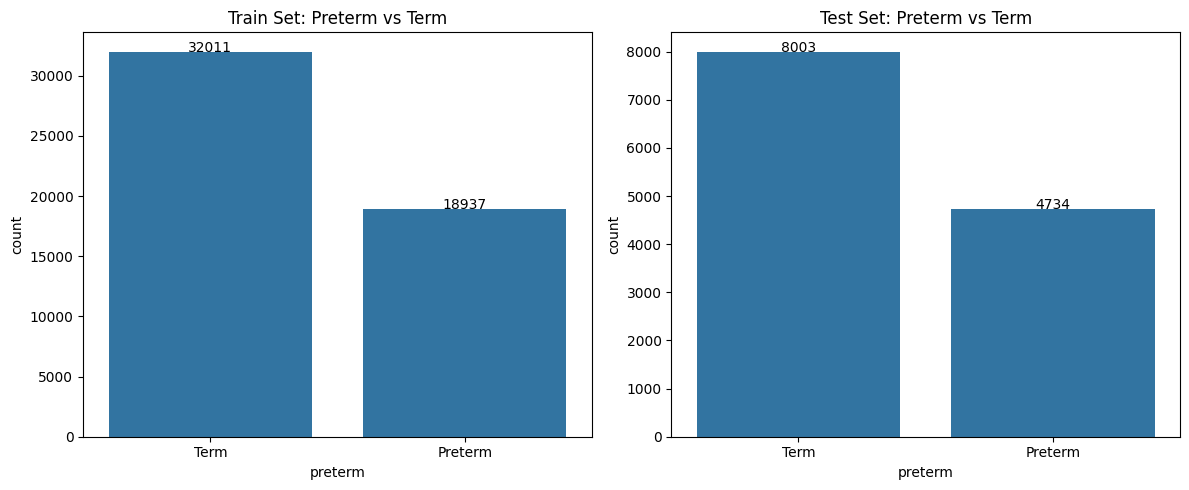

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Term','Preterm'])
axes[0].set_title('Train Set: Preterm vs Term')
for p in axes[0].patches:
    # print(p)
    height = p.get_height()
    axes[0].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')

    

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Term','Preterm'])
axes[1].set_title('Test Set: Preterm vs Term')
for p in axes[1].patches:
    # print(p)
    height = p.get_height()
    axes[1].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.tight_layout()
plt.show()


In [19]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
corr = X_train[numeric_cols].corr()

# Identify highly correlated pairs (threshold >0.9)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.88:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

corr_pairs


[('mager14', 'mager', np.float64(0.9422980471782502)),
 ('mager9', 'mager', np.float64(0.9732409939883578)),
 ('mager9', 'mager14', np.float64(0.9621479513446263)),
 ('mrace6', 'mrace31', np.float64(0.9315751173830538)),
 ('mrace15', 'mrace31', np.float64(0.9039572098896145)),
 ('mrace15', 'mrace6', np.float64(0.9652356137357883)),
 ('fagerec11', 'fagecomb', np.float64(0.944586257256304)),
 ('frace6', 'frace31', np.float64(0.9245904540433578)),
 ('frace15', 'frace31', np.float64(0.998197457458881)),
 ('frace15', 'frace6', np.float64(0.9429673684512346)),
 ('illb_r11', 'illb_r', np.float64(0.9987181376265086)),
 ('ilop_r11', 'ilop_r', np.float64(0.9992822895949599)),
 ('ilp_r11', 'ilp_r', np.float64(0.9989605267546451)),
 ('cig_1', 'cig_0', np.float64(0.9943076494339801)),
 ('cig_2', 'cig_0', np.float64(0.9945344322625138)),
 ('cig_2', 'cig_1', np.float64(0.9986525492088405)),
 ('cig0_r', 'cig_0', np.float64(0.9927844287903632)),
 ('cig0_r', 'cig_1', np.float64(0.9843573214079575)),
 ('

In [20]:
# # Convert to a matrix
# df_pairs = pd.DataFrame(corr_pairs, columns=['Feature1', 'Feature2', 'Correlation'])

# # Pivot into matrix form
# corr_matrix = df_pairs.pivot(index='Feature1', columns='Feature2', values='Correlation')

# # Plot heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# plt.title("Heatmap of Highly Correlated Feature Pairs")

# plt.show()

In [21]:
cols_to_drop = ['mager14', 'mager9', 'mrace31', 'mrace15', 'frace31', 'frace15',
                'lbo_rec', 'wtgain_rec', 'ilp_r11', 'ilop_r11', 'illb_r11', 'bmi_r', 'pwgt_r', 'fagerec11',
                'cig_3', 'cig_1', 'cig_0', 'cig_2']


In [22]:
X_train = X_train.drop(columns=cols_to_drop)
print(X_train.shape)


(50948, 50)


In [23]:
X_test = X_test.drop(columns = cols_to_drop)
print(X_test.shape)

(12737, 50)


In [24]:
X_train = X_train.drop(columns=['previs', 'precare', 'no_risks', 'no_infec', 'cig_rec'])

In [25]:
X_test = X_test.drop(columns=['previs', 'precare', 'no_risks', 'no_infec', 'cig_rec'])

In [26]:
X_train = X_train.drop(columns=['dwgt_r', 'ld_ster', 'setorder_r',
'ld_chor'])
X_test = X_test.drop(columns=['dwgt_r', 'ld_ster', 'setorder_r',
'ld_chor'])

In [27]:
print(X_train.shape)
print(X_test.shape)

(50948, 41)
(12737, 41)


In [28]:
X_train['dplural'].unique()

array([1, 2, 3, 4])

In [29]:
X_train['dmar'].unique()

array([2, 1])

# Data Preprocessing

# Step 1: Continuous / Numeric Features Preprocessing   (12)

In [30]:
numeric_continuous_features = ['mager', 'fagecomb',
       'priorlive', 'priordead', 'priorterm', 'illb_r', 'ilop_r',
       'ilp_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']
len(numeric_continuous_features)


12

In [31]:
unknown_code_map = {
    'fagecomb' : 99, 'priorlive': 99,'priordead': 99,'priorterm': 99,'illb_r': 999,'ilop_r': 999,'ilp_r': 999,'m_ht_in': 99,
    'bmi': 99.9,'wtgain': 99,'rf_cesarn': 99
}
len(unknown_code_map)

11

In [32]:
unknown_code_map.items()

dict_items([('fagecomb', 99), ('priorlive', 99), ('priordead', 99), ('priorterm', 99), ('illb_r', 999), ('ilop_r', 999), ('ilp_r', 999), ('m_ht_in', 99), ('bmi', 99.9), ('wtgain', 99), ('rf_cesarn', 99)])

In [33]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in dataset.columns:
        X_train[col] = X_train[col].replace(code, np.nan)

In [34]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in dataset.columns:
        X_test[col] = X_test[col].replace(code, np.nan)

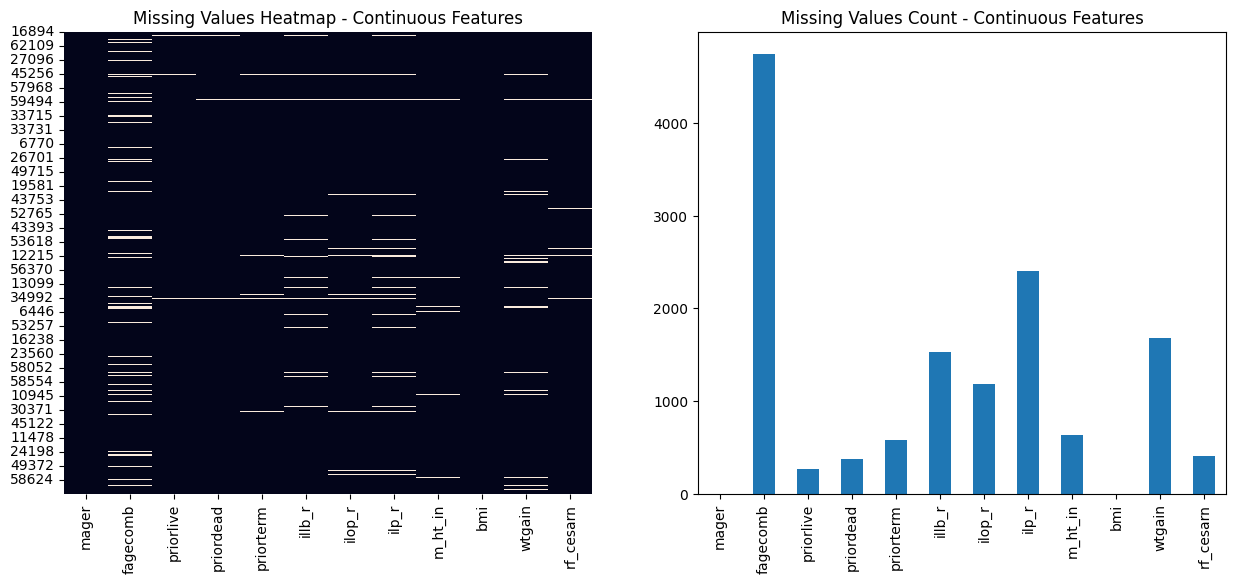

In [35]:

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.heatmap(X_train[numeric_continuous_features].isna(), cbar=False)
plt.title("Missing Values Heatmap - Continuous Features")
# plt.show()

plt.subplot(1, 2, 2)
X_train[numeric_continuous_features].isna().sum().plot(kind='bar')
plt.title("Missing Values Count - Continuous Features")
plt.show()


In [36]:
(X_train[numeric_continuous_features].isnull().sum()/X_train.shape[0])*100

mager        0.000000
fagecomb     9.319306
priorlive    0.524064
priordead    0.726231
priorterm    1.132527
illb_r       3.003062
ilop_r       2.321975
ilp_r        4.708723
m_ht_in      1.234592
bmi          0.000000
wtgain       3.293554
rf_cesarn    0.804742
dtype: float64

# Step 2: Ordinal Features Preprocessing (11)

In [37]:
ordinal_features = ['meduc', 'feduc',  'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r',  'precare5', 'previs_rec',  'dplural', 'tbo_rec', 'dmar']
len(ordinal_features)

11

# Step 3: One-Hot Features (16)

In [38]:

# all_features = X_train.columns.tolist()
# one_hot_features = list(set(all_features) - set(numeric_continuous_features) - set(ordinal_features))
# print(one_hot_features)
# len(one_hot_features)

one_hot_features = ['ip_gon', 'ip_chlam', 'rf_ghype', 'rf_cesar', 'rf_inftr', 'rf_phype', 'rf_artec', 'ip_hepb', 'mar_p', 'rf_ppterm', 'ip_syph','rf_pdiab', 'rf_ehype', 'ip_hepc', 'rf_gdiab', 'rf_fedrg']
len(one_hot_features)

16

In [39]:
pip install numpy


In [40]:
print(X_train[numeric_continuous_features].dtypes)

mager          int64
fagecomb     float64
priorlive    float64
priordead    float64
priorterm    float64
illb_r       float64
ilop_r       float64
ilp_r        float64
m_ht_in      float64
bmi          float64
wtgain       float64
rf_cesarn    float64
dtype: object


# Build Preprocessing Pipeline

In [41]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [42]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = 'passthrough'

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [43]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numeric_continuous_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('onehot', categorical_pipeline, one_hot_features)
    ]
)

In [44]:
def normalize_missing(df):
    return (
        df
        .replace({pd.NA: np.nan})
        .infer_objects(copy=False)
    )

X_train = normalize_missing(X_train)
X_test = normalize_missing(X_test)


In [45]:
# # Ordinal
# print("Ordinal features missing values:")
# print(X_train[ordinal_features].isna().sum())

# # One-hot
# print("One-hot features missing values:")
# print(X_train[one_hot_features].isna().sum())

In [46]:
print("Numeric Continuous missing values:")
print(X_train[numeric_continuous_features].isna().sum())

Numeric Continuous missing values:
mager           0
fagecomb     4748
priorlive     267
priordead     370
priorterm     577
illb_r       1530
ilop_r       1183
ilp_r        2399
m_ht_in       629
bmi             0
wtgain       1678
rf_cesarn     410
dtype: int64


In [47]:
for ordi in ordinal_features:
    print(ordi, X_train[ordi].unique())

meduc [3 2 6 7 4 5 1 8 9]
feduc [9 2 3 6 4 5 7 1 8]
cig0_r [0 6 1 2 3 5 4]
cig1_r [0 6 1 3 2 4 5]
cig2_r [0 6 1 3 2 5 4]
cig3_r [0 6 1 3 2 4 5]
precare5 [2 5 3 1 4]
previs_rec [ 3 12  8 11  6  4  7  9  1 10  2  5]
dplural [1 2 3 4]
tbo_rec [1 4 3 2 5 7 6 8 9]
dmar [2 1]


In [48]:
for col in one_hot_features:
    print(col, X_train[col].dtype, X_train[col].unique())


ip_gon object ['N' 'U' 'Y']
ip_chlam object ['N' 'Y' 'U']
rf_ghype object ['N' 'Y' 'U']
rf_cesar object ['N' 'Y' 'U']
rf_inftr object ['N' 'U' 'Y']
rf_phype object ['N' 'Y' 'U']
rf_artec object ['X' 'U' 'Y' 'N']
ip_hepb object ['N' 'U' 'Y']
mar_p object ['N' 'X' 'Y' 'U']
rf_ppterm object ['N' 'Y' 'U']
ip_syph object ['N' 'Y' 'U']
rf_pdiab object ['N' 'Y' 'U']
rf_ehype object ['N' 'U' 'Y']
ip_hepc object ['N' 'U' 'Y']
rf_gdiab object ['N' 'Y' 'U']
rf_fedrg object ['X' 'U' 'N' 'Y']


In [49]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [50]:
X_train_processed

array([[-1.24603075, -0.17869016, -0.77089263, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.74836483, -0.17869016, -0.77089263, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.24696372,  3.55117343,  1.81670621, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.41503259, -0.45497635,  0.09164032, ...,  0.        ,
         1.        ,  0.        ],
       [-0.91363149,  0.37388222, -0.77089263, ...,  0.        ,
         1.        ,  0.        ],
       [-1.07983112, -0.17869016, -0.77089263, ...,  0.        ,
         1.        ,  0.        ]], shape=(50948, 74))

In [51]:
X_test_processed

array([[-1.57843001, -1.14569183, -0.77089263, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.41596556,  1.61717009,  0.95417326, ...,  0.        ,
         1.        ,  0.        ],
       [-1.74462964, -1.56012112, -0.77089263, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.24883296, -0.73126255, -0.77089263, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.91176225,  2.30788557,  1.81670621, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41223038, -0.31683326, -0.77089263, ...,  0.        ,
         1.        ,  0.        ]], shape=(12737, 74))

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [62]:
# joblib.dump(best_model, "final_preterm_full_pipeline.pkl")


In [63]:

# pipe = joblib.load("final_preterm_full_pipeline.pkl")
# print(type(pipe))
# print(pipe)

# Logistic Regression hyperparameter tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
log_pip = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
        solver="saga",
        class_weight={0:1, 1:2.5}
    ))
]
)

param_grid = {
    "model__C":[0.01, 0.1, 1, 10],
    "model__penalty":['l1', 'l2']
}

In [ ]:
log_random = RandomizedSearchCV(
    estimator = log_pip,
    param_distributions=param_grid,
    n_iter=8,
    cv=3,
    verbose=2,
    scoring='roc_auc',
    random_state = 42,
    n_jobs=-1
)
log_random.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
best_log = log_random.best_estimator_
y_pred = best_log.predict(X_test)
y_prob = best_log.predict_proba(X_test)[:, 1]
print(y_pred)
print(y_prob)
print("Best params:", log_random.best_params_)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
# 

In [ ]:
# import pandas as pd

# sample_data = pd.DataFrame([{
#     'mager': 28,
#     'fagecomb': 30,
#     'priorlive': 1,
#     'priordead': 0,
#     'priorterm': 0,
#     'illb_r': 12,
#     'ilop_r': 0,
#     'ilp_r': 0,
#     'm_ht_in': 64,
#     'bmi': 24.5,
#     'wtgain': 20,
#     'rf_cesarn': 0,
#     'meduc': 6,
#     'feduc': 6,
#     'cig0_r': 0,
#     'cig1_r': 0,
#     'cig2_r': 0,
#     'cig3_r': 0,
#     'precare5': 2,
#     'previs_rec': 3,
#     'dplural': 1,
#     'tbo_rec': 1,
#     'dmar': '1',       # now categorical string
#     'rf_ehype': 'N',
#     'rf_ghype': 'N',
#     'ip_syph': 'N',
#     'rf_inftr': 'N',
#     'rf_pdiab': 'N',
#     'rf_cesar': 'N',
#     'rf_phype': 'N',
#     'ip_gon': 'N',
#     'mar_p': 'N',
#     'rf_fedrg': 'N',
#     'ip_chlam': 'N',
#     'rf_artec': 'N',
#     'rf_ppterm': 'N',
#     'ip_hepb': 'N',
#     'ip_hepc': 'N',
#     'rf_gdiab': 'N',
#     'eclampsia': 'N',
#     'prev_preterm': 'N',
#     'infertility_treat': 'N',
#     'fertility_drugs': 'N',
#     'art': 'N',
#     'prev_csection': 'N'
# }])

# # Prediction
# pred = best_model.predict(sample_data)[0]
# prob = best_model.predict_proba(sample_data)[0,1]

# print("Prediction:", pred)
# print("Risk probability:", prob)


In [ ]:
# import joblib
# joblib.dump(best_model, "final_preterm_full_pipeline.pkl")

In [ ]:
# pipe = joblib.load("final_preterm_full_pipeline.pkl")
# print(type(pipe))
# print(pipe)